In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [55]:
import zipfile
import os

zip_file = "/content/archive (4).zip"
extract_path = "/content/leaf_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [56]:
# Check the extracted dataset structure

for root, dirs, files in os.walk("/content/leaf_dataset"):
    print(root, "→", len(files), "files")

/content/leaf_dataset → 0 files
/content/leaf_dataset/aug_data → 0 files
/content/leaf_dataset/aug_data/aug_data → 0 files
/content/leaf_dataset/aug_data/aug_data/masks → 2940 files
/content/leaf_dataset/aug_data/aug_data/images → 2940 files
/content/leaf_dataset/data → 0 files
/content/leaf_dataset/data/data → 0 files
/content/leaf_dataset/data/data/masks → 588 files
/content/leaf_dataset/data/data/images → 588 files


In [57]:
images_path = "/content/leaf_dataset/aug_data/aug_data/images"
masks_path = "/content/leaf_dataset/aug_data/aug_data/masks"

image_files = sorted(os.listdir(images_path))
mask_files = sorted(os.listdir(masks_path))

print("Images:", len(image_files))
print("Masks:", len(mask_files))

Images: 2940
Masks: 2940


In [58]:
image = cv2.imread(os.path.join(images_path, image_files[0]))
mask = cv2.imread(os.path.join(masks_path, mask_files[0]), cv2.IMREAD_GRAYSCALE)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Image shape: (235, 326, 3)
Mask shape: (235, 326)


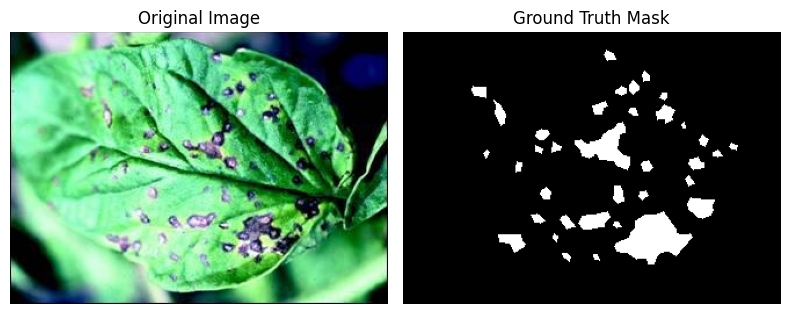

In [59]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [60]:
# Preprocessing

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

In [61]:
# Disease region segmentation using Otsu thresholding

_, otsu_mask = cv2.threshold(
    blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Otsu threshold value:", _)

Otsu threshold value: 117.0


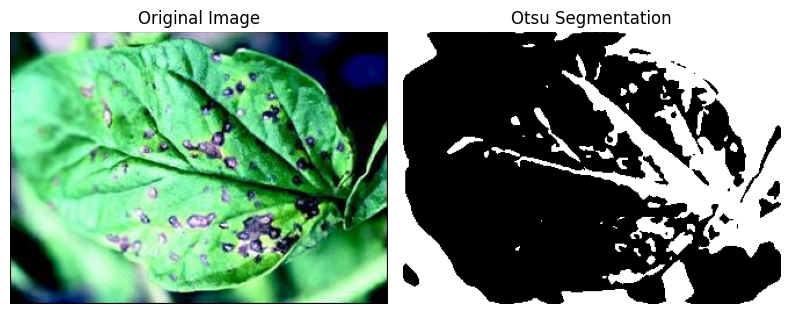

In [62]:
# Display Otsu segmentation result

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(otsu_mask, cmap="gray")
plt.title("Otsu Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

In [63]:
# Morphological post-processing

kernel = np.ones((5, 5), np.uint8)

clean_mask = cv2.morphologyEx(otsu_mask, cv2.MORPH_OPEN, kernel)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

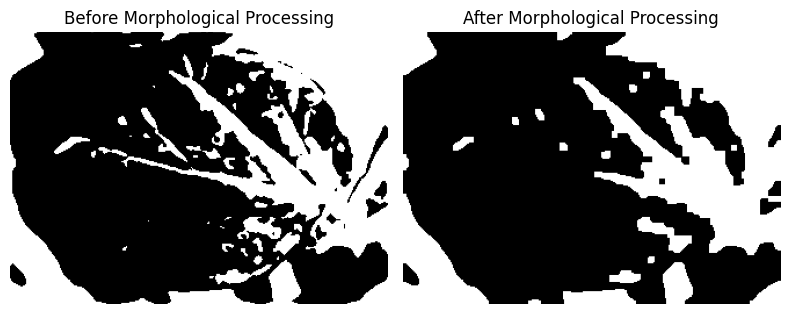

In [64]:
# Display the cleaned segmentation result

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(otsu_mask, cmap="gray")
plt.title("Before Morphological Processing")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_mask, cmap="gray")
plt.title("After Morphological Processing")
plt.axis("off")

plt.tight_layout()
plt.show()

In [65]:
# Compare segmentation with ground truth

ground_truth = (mask > 0).astype(np.uint8)
predicted = (clean_mask > 0).astype(np.uint8)

intersection = np.logical_and(ground_truth, predicted).sum()
union = np.logical_or(ground_truth, predicted).sum()

iou = intersection / union if union > 0 else 0
dice = (2 * intersection) / (ground_truth.sum() + predicted.sum()) if (ground_truth.sum() + predicted.sum()) > 0 else 0
accuracy = (ground_truth == predicted).mean()

print("IoU:", round(iou, 4))
print("Dice Coefficient:", round(dice, 4))
print("Accuracy:", round(accuracy, 4))

IoU: 0.0594
Dice Coefficient: 0.1122
Accuracy: 0.6537


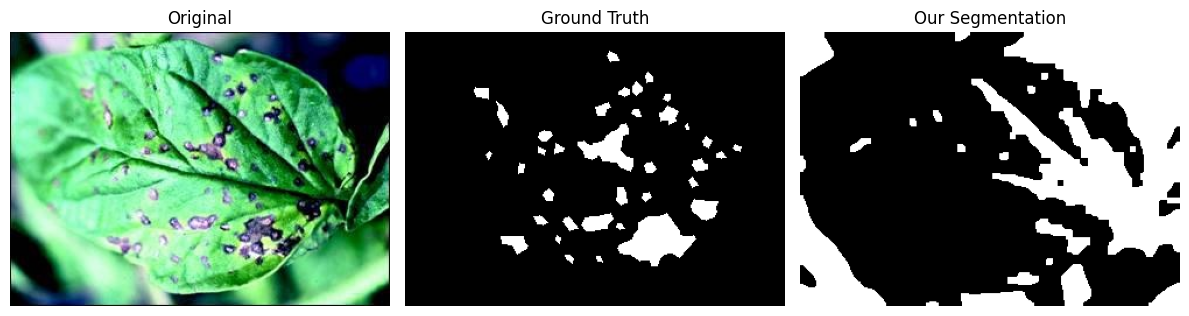

In [66]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted, cmap="gray")
plt.title("Our Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

In [67]:
adaptive_mask = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)

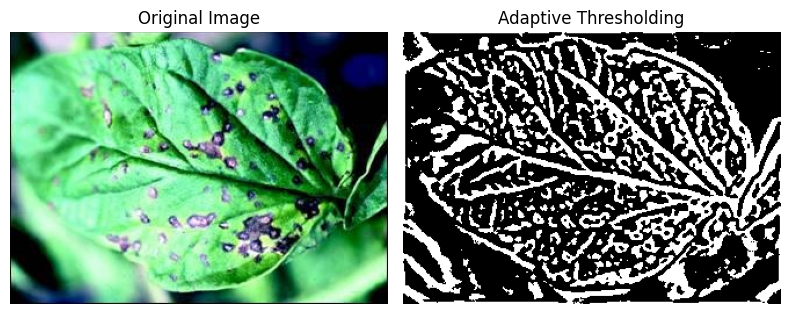

In [68]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(adaptive_mask, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.tight_layout()
plt.show()

In [69]:
# Evaluate adaptive thresholding

adaptive_binary = (adaptive_mask > 0).astype(np.uint8)

intersection = np.logical_and(ground_truth, adaptive_binary).sum()
union = np.logical_or(ground_truth, adaptive_binary).sum()

iou_adaptive = intersection / union if union > 0 else 0
dice_adaptive = (2 * intersection) / (ground_truth.sum() + adaptive_binary.sum()) if (ground_truth.sum() + adaptive_binary.sum()) > 0 else 0
accuracy_adaptive = (ground_truth == adaptive_binary).mean()

print("Adaptive Thresholding")
print("IoU:", round(iou_adaptive, 4))
print("Dice Coefficient:", round(dice_adaptive, 4))
print("Accuracy:", round(accuracy_adaptive, 4))

Adaptive Thresholding
IoU: 0.1152
Dice Coefficient: 0.2065
Accuracy: 0.6792


In [70]:
edges = cv2.Canny(blurred, 50, 150)

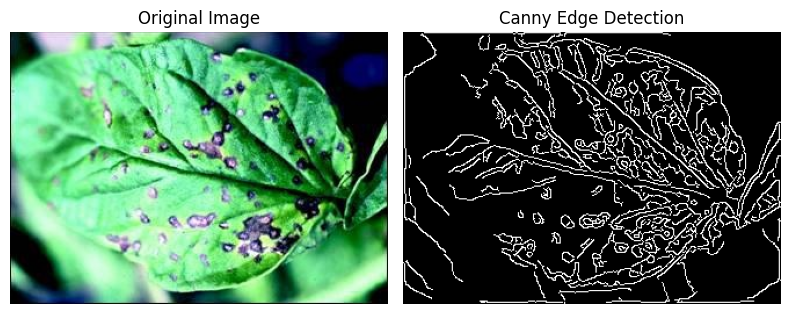

In [71]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
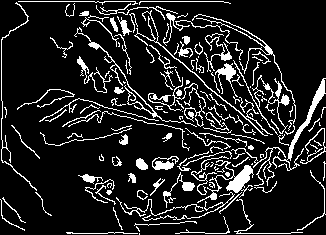

In [72]:
# Convert Canny edges into a filled segmentation mask

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

canny_mask = np.zeros_like(edges)
cv2.drawContours(canny_mask, contours, -1, 255, thickness=cv2.FILLED)

In [73]:
canny_binary = (canny_mask > 0).astype(np.uint8)

intersection = np.logical_and(ground_truth, canny_binary).sum()
union = np.logical_or(ground_truth, canny_binary).sum()

iou_canny = intersection / union if union > 0 else 0
dice_canny = (2 * intersection) / (ground_truth.sum() + canny_binary.sum()) if (ground_truth.sum() + canny_binary.sum()) > 0 else 0
accuracy_canny = (ground_truth == canny_binary).mean()

print("Canny Edge Segmentation")
print("IoU:", round(iou_canny, 4))
print("Dice Coefficient:", round(dice_canny, 4))
print("Accuracy:", round(accuracy_canny, 4))

Canny Edge Segmentation
IoU: 0.1649
Dice Coefficient: 0.2831
Accuracy: 0.8517


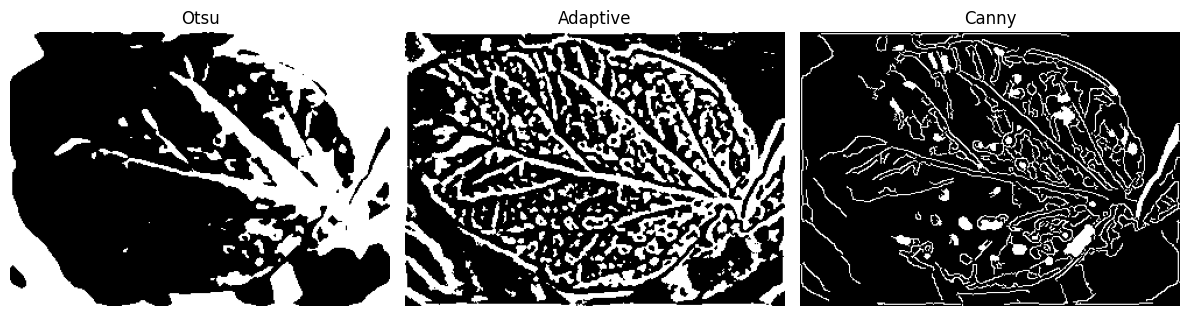

In [82]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(otsu_mask, cmap="gray")
plt.title("Otsu")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adaptive_mask, cmap="gray")
plt.title("Adaptive")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canny_mask, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

In [85]:
# Evaluate the methods on 50 images

n = 50

otsu_scores = []
adaptive_scores = []
canny_scores = []

for i in range(n):
    img = cv2.imread(os.path.join(images_path, image_files[i]))
    gt = cv2.imread(os.path.join(masks_path, mask_files[i]), cv2.IMREAD_GRAYSCALE)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, o_mask = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    a_mask = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    edge = cv2.Canny(blur, 50, 150)
    contours, _ = cv2.findContours(
        edge, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    c_mask = np.zeros_like(edge)
    cv2.drawContours(c_mask, contours, -1, 255, cv2.FILLED)

    gt = (gt > 0).astype(np.uint8)

    for pred, scores in [
        ((o_mask > 0).astype(np.uint8), otsu_scores),
        ((a_mask > 0).astype(np.uint8), adaptive_scores),
        ((c_mask > 0).astype(np.uint8), canny_scores)
    ]:
        intersection = np.logical_and(gt, pred).sum()
        union = np.logical_or(gt, pred).sum()

        iou_score = intersection / union if union > 0 else 0
        scores.append(iou_score)

print("Average IoU - Otsu:", round(np.mean(otsu_scores), 4))
print("Average IoU - Adaptive:", round(np.mean(adaptive_scores), 4))
print("Average IoU - Canny:", round(np.mean(canny_scores), 4))

Average IoU - Otsu: 0.0711
Average IoU - Adaptive: 0.1547
Average IoU - Canny: 0.1419


In [86]:
# Calculate average Dice and Accuracy for 50 images

dice_scores = []
accuracy_scores = []

for i in range(n):
    img = cv2.imread(os.path.join(images_path, image_files[i]))
    gt = cv2.imread(os.path.join(masks_path, mask_files[i]), cv2.IMREAD_GRAYSCALE)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    pred = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )

    gt = (gt > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)

    intersection = np.logical_and(gt, pred).sum()

    dice = (2 * intersection) / (gt.sum() + pred.sum()) if (gt.sum() + pred.sum()) > 0 else 0
    accuracy = (gt == pred).mean()

    dice_scores.append(dice)
    accuracy_scores.append(accuracy)

print("Average Dice:", round(np.mean(dice_scores), 4))
print("Average Accuracy:", round(np.mean(accuracy_scores), 4))

Average Dice: 0.2565
Average Accuracy: 0.7388


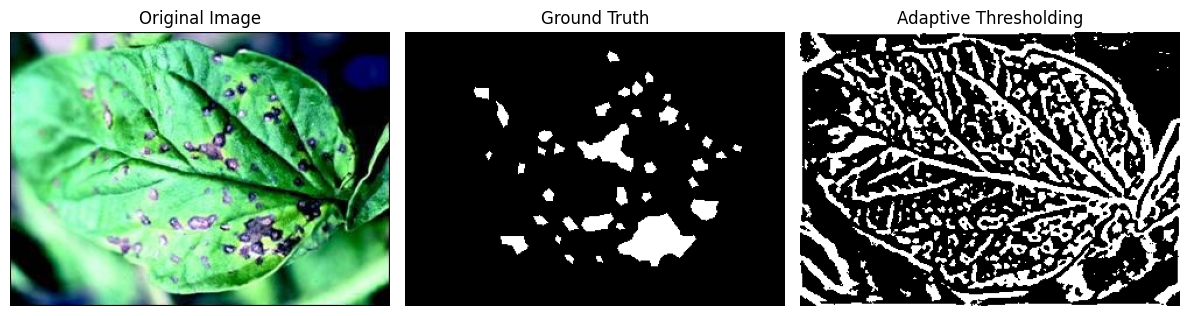

In [87]:
# Final segmentation result using Adaptive Thresholding

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(adaptive_mask, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.tight_layout()
plt.show()

In [88]:
# Affected area and severity using Adaptive Thresholding

best_mask = (adaptive_mask > 0).astype(np.uint8)

total_pixels = best_mask.size
affected_pixels = np.sum(best_mask)

affected_percentage = (affected_pixels / total_pixels) * 100

if affected_percentage < 10:
    severity = "Low"
elif affected_percentage < 30:
    severity = "Moderate"
else:
    severity = "High"

print("Estimated Affected Area:", round(affected_percentage, 2), "%")
print("Estimated Severity:", severity)

Estimated Affected Area: 33.57 %
Estimated Severity: High


In [89]:
# Compare affected area

gt_area = (ground_truth > 0).mean() * 100
pred_area = (adaptive_mask > 0).mean() * 100

print("Ground Truth Affected Area:", round(gt_area, 2), "%")
print("Predicted Affected Area:", round(pred_area, 2), "%")

Ground Truth Affected Area: 6.86 %
Predicted Affected Area: 33.57 %


In [90]:
# Final comparison of segmentation methods

print("FINAL 50-IMAGE RESULTS")
print("----------------------")
print("Otsu      - IoU:", round(np.mean(otsu_scores), 4))
print("Adaptive  - IoU:", round(np.mean(adaptive_scores), 4))
print("Canny     - IoU:", round(np.mean(canny_scores), 4))

print("\nAdaptive Thresholding")
print("Average Dice:", round(np.mean(dice_scores), 4))
print("Average Accuracy:", round(np.mean(accuracy_scores), 4))

print("\nSample Severity Analysis")
print("Ground Truth Area:", round(gt_area, 2), "%")
print("Predicted Area:", round(pred_area, 2), "%")

FINAL 50-IMAGE RESULTS
----------------------
Otsu      - IoU: 0.0711
Adaptive  - IoU: 0.1547
Canny     - IoU: 0.1419

Adaptive Thresholding
Average Dice: 0.2565
Average Accuracy: 0.7388

Sample Severity Analysis
Ground Truth Area: 6.86 %
Predicted Area: 33.57 %


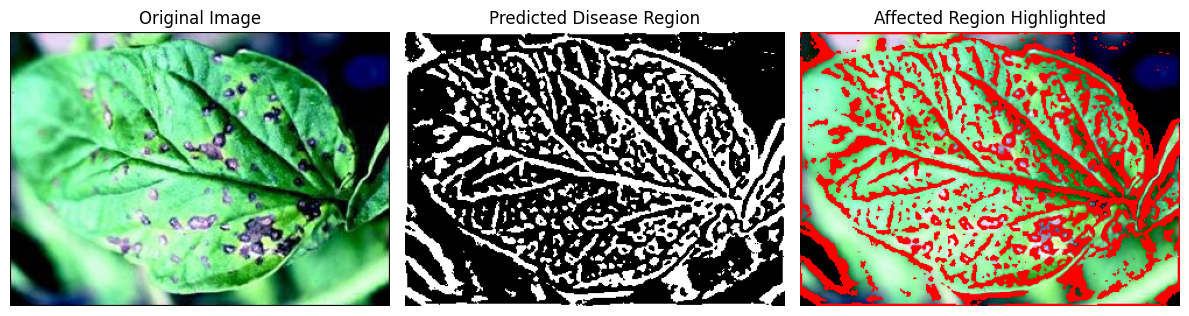

In [91]:
# Highlight the predicted disease region

highlight = image_rgb.copy()
highlight[adaptive_mask > 0] = [255, 0, 0]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adaptive_mask, cmap="gray")
plt.title("Predicted Disease Region")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(highlight)
plt.title("Affected Region Highlighted")
plt.axis("off")

plt.tight_layout()
plt.show()

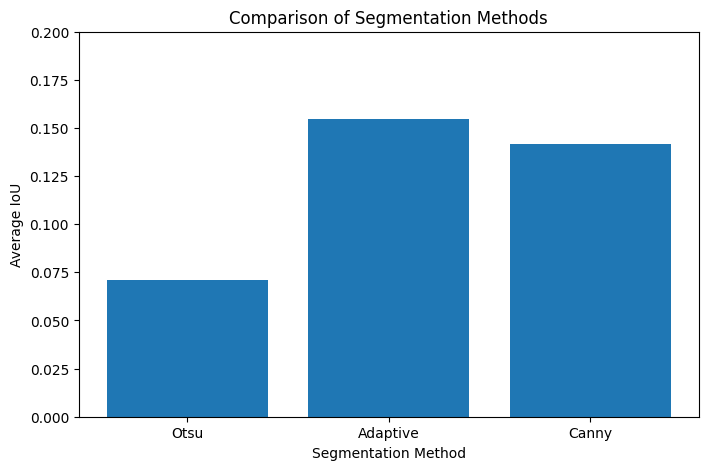

In [92]:
# Final IoU Comparison

methods = ["Otsu", "Adaptive", "Canny"]

iou_scores = [
    np.mean(otsu_scores),
    np.mean(adaptive_scores),
    np.mean(canny_scores)
]

plt.figure(figsize=(8, 5))

plt.bar(methods, iou_scores)

plt.xlabel("Segmentation Method")
plt.ylabel("Average IoU")
plt.title("Comparison of Segmentation Methods")

plt.ylim(0, 0.2)

plt.show()